In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

In [2]:
df = pd.read_csv("/content/Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print(df.shape)

df.info()

df.describe()

(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [4]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [5]:
df = df.drop(
    ["RowNumber","CustomerId","Surname"],
    axis=1
)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [17]:
from sklearn.preprocessing import LabelEncoder

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

le = LabelEncoder()

# Encode gender column safely
if "Gender" in df.columns:
    df["Gender"] = le.fit_transform(df["Gender"])

elif "Sex" in df.columns:
    df["Sex"] = le.fit_transform(df["Sex"])

else:
    print("No Gender/Sex column found")
    print(df.columns)

# One-hot encoding for Geography if present
if "Geography" in df.columns:
    df = pd.get_dummies(
        df,
        columns=["Geography"],
        drop_first=True,
        dtype=int
    )

df.head()

No Gender/Sex column found
Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


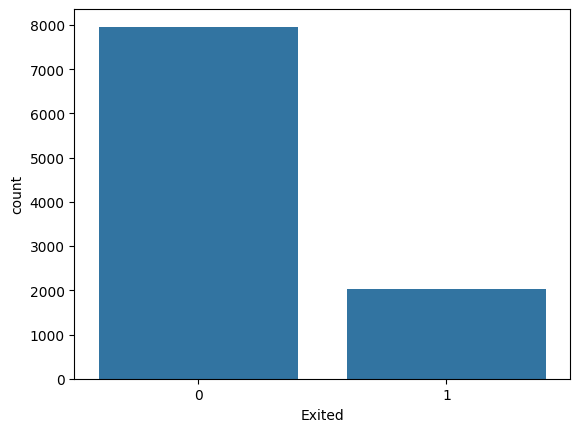

In [18]:
sns.countplot(
    x="Exited",
    data=df
)

plt.show()

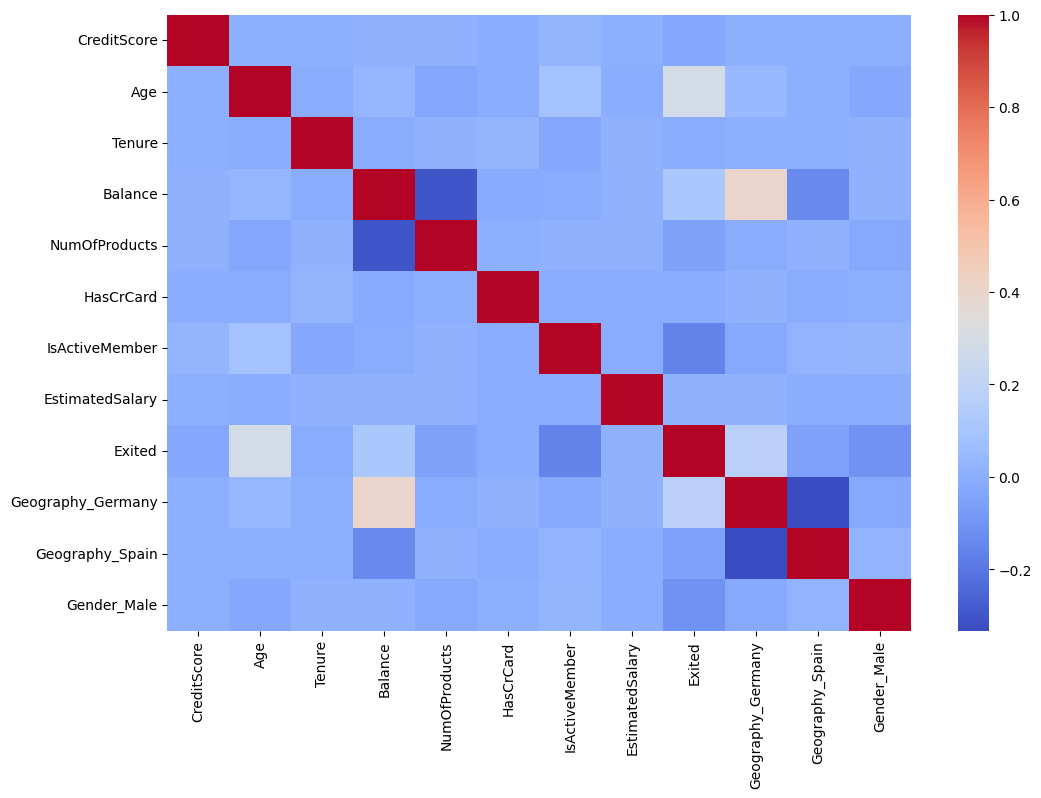

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.show()

In [21]:
# Feature Engineering

# Balance Salary Ratio
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)

# Age Groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 100],
    labels=[0, 1, 2, 3],
    include_lowest=True
).astype("int64")

# Display updated dataframe
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,BalanceSalaryRatio,AgeGroup
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False,0.000000,2
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False,0.744670,2
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False,1.401362,2
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False,0.000000,1
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False,1.587035,2


In [22]:
X=df.drop(
    "Exited",
    axis=1
)

y=df["Exited"]

In [23]:
X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

In [24]:
scaler=StandardScaler()

X_train=scaler.fit_transform(
    X_train
)

X_test=scaler.transform(
    X_test
)

In [25]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred=lr.predict(
    X_test
)

In [26]:
print(
accuracy_score(
y_test,
lr_pred
))

print(

classification_report(
y_test,
lr_pred
)

)

0.828
              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1607
           1       0.66      0.25      0.37       393

    accuracy                           0.83      2000
   macro avg       0.75      0.61      0.63      2000
weighted avg       0.81      0.83      0.80      2000



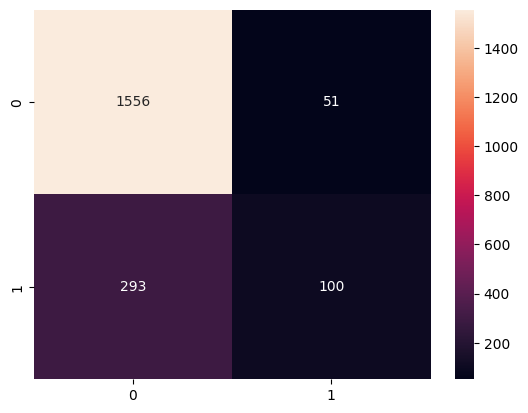

In [27]:
cm=confusion_matrix(
y_test,
lr_pred
)

sns.heatmap(
cm,
annot=True,
fmt="d"
)

plt.show()

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
n_estimators=200,
random_state=42
)

rf.fit(
X_train,
y_train
)

rf_pred=rf.predict(
X_test
)

In [29]:
print(
accuracy_score(
y_test,
rf_pred
))

print(
classification_report(
y_test,
rf_pred
)
)

0.8695
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.48      0.59       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



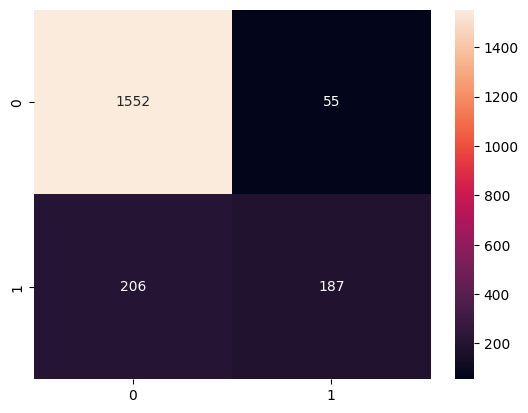

In [30]:
cm=confusion_matrix(
y_test,
rf_pred
)

sns.heatmap(
cm,
annot=True,
fmt="d"
)

plt.show()

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

gb=GradientBoostingClassifier()

gb.fit(
X_train,
y_train
)

gb_pred=gb.predict(
X_test
)

In [32]:
print(
accuracy_score(
y_test,
gb_pred
))

print(
classification_report(
y_test,
gb_pred
))

0.8675
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.49      0.59       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



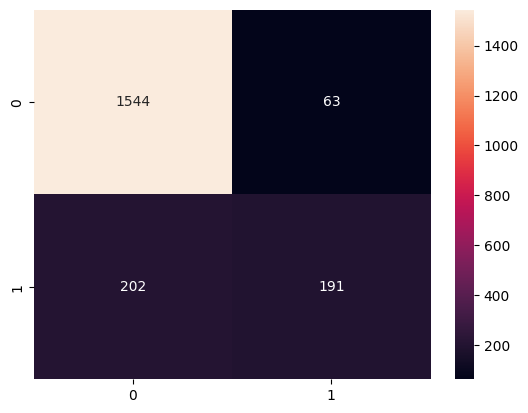

In [33]:
cm=confusion_matrix(
y_test,
gb_pred
)

sns.heatmap(
cm,
annot=True,
fmt="d"
)

plt.show()

In [34]:
results=pd.DataFrame({

"Model":[

"Logistic",

"Random Forest",

"Gradient Boost"

],

"Accuracy":[

accuracy_score(
y_test,
lr_pred
),

accuracy_score(
y_test,
rf_pred
),

accuracy_score(
y_test,
gb_pred
)

]

})

results

,Model,Accuracy
0,Logistic,0.8280
1,Random Forest,0.8695
2,Gradient Boost,0.8675


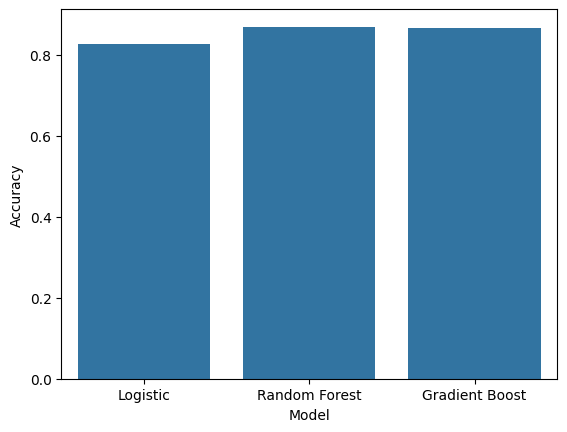

In [35]:
sns.barplot(

x="Model",

y="Accuracy",

data=results

)

plt.show()

In [36]:
best_model=rf

print(
"Best Model Selected = Random Forest"
)

Best Model Selected = Random Forest


In [37]:
best_pred=best_model.predict(
X_test
)

print(

classification_report(
y_test,
best_pred
)

)

print(

"ROC AUC:",

roc_auc_score(
y_test,
best_pred
)

)

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.48      0.59       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000

ROC AUC: 0.7208008537711128


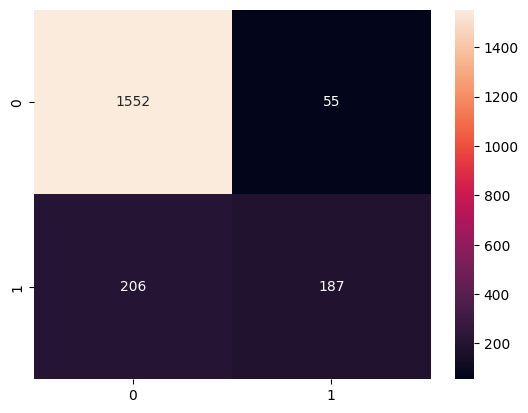

In [38]:
cm=confusion_matrix(
y_test,
best_pred
)

sns.heatmap(
cm,
annot=True,
fmt="d"
)

plt.show()

In [42]:
def predict_churn():

    while True:

        print("\nEnter Customer Details\n")

        credit=int(input("Credit Score: "))

        gender=input(
            "Gender Male/Female: "
        )

        geography=input(
            "Geography France/Spain/Germany: "
        )

        age=int(
            input("Age: ")
        )

        tenure=int(
            input("Tenure: ")
        )

        balance=float(
            input("Balance: ")
        )

        products=int(
            input("Products: ")
        )

        card=int(
            input("Has Card 0/1: ")
        )

        active=int(
            input("Active Member 0/1: ")
        )

        salary=float(
            input("Salary: ")
        )


        gender=1 if gender.lower()=="male" else 0

        geo_france=0
        geo_germany=0


        if geography.lower()=="germany":

            geo_germany=1

        elif geography.lower()=="spain":

            geo_france=1



        ratio=balance/(salary+1)



        if age<30:

            agegroup=0

        elif age<40:

            agegroup=1

        elif age<50:

            agegroup=2

        else:

            agegroup=3



        data=np.array([[
            credit,
            gender,
            age,
            tenure,
            balance,
            products,
            card,
            active,
            salary,
            geo_france,
            geo_germany,
            ratio,
            agegroup
        ]])


        data=scaler.transform(data)


        probabilities=best_model.predict_proba(
            data
        )[0]


        prediction=best_model.predict(
            data
        )[0]


        churn_prob=probabilities[1]

        stay_prob=probabilities[0]



        print("\n------RESULT------")


        if prediction==1:

            print(
                "Prediction: Customer likely to churn"
            )

        else:

            print(
                "Prediction: Customer unlikely to churn"
            )



        print(
            "Confidence:",
            round(
                max(probabilities)*100,
                2
            ),
            "%"
        )


        print(
            "Probability of Churn:",
            round(
                churn_prob*100,
                2
            ),
            "%"
        )


        print(
            "Probability of Staying:",
            round(
                stay_prob*100,
                2
            ),
            "%"
        )



        cont=input(
            "\nDo you want to continue? (yes/no): "
        ).lower()



        if cont!="yes":

            print(
                "\nPrediction System Closed"
            )

            break

In [ ]:
predict_churn()


Enter Customer Details

Credit Score: 720
Gender Male/Female: Male
Geography France/Spain/Germany: France
Age: 32
Tenure: 7
Balance: 45000
Products: 2
Has Card 0/1: 1
Active Member 0/1: 1
Salary: 85000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



------RESULT------
Prediction: Customer unlikely to churn
Confidence: 50.0 %
Probability of Churn: 50.0 %
Probability of Staying: 50.0 %
